# Imports

In [27]:
import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms

# Pre Data Augmentation

[cats] cat.11994.jpg - Raw Size: (150, 149)
[cats] cat.2510.jpg - Raw Size: (499, 375)
[cats] cat.9194.jpg - Raw Size: (156, 263)
[cats] cat.10194.jpg - Raw Size: (499, 464)
[dogs] dog.5592.jpg - Raw Size: (159, 120)
[dogs] dog.8016.jpg - Raw Size: (199, 258)
[dogs] dog.9878.jpg - Raw Size: (499, 375)
[dogs] dog.5487.jpg - Raw Size: (500, 374)


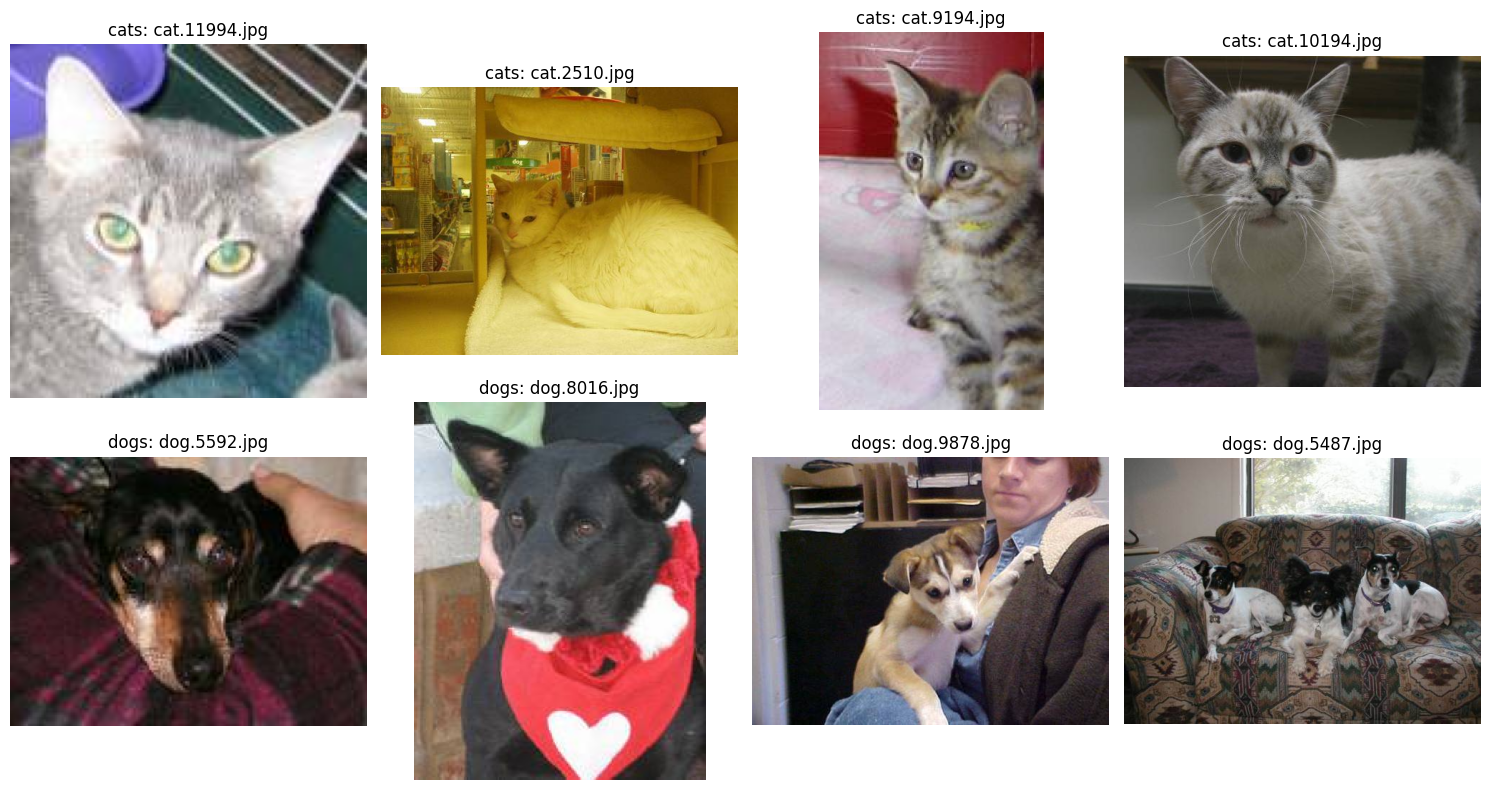

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data_path = 'ecse-415-winter-2026-dog-vs-cat-classification/train/train'

def show_random_samples(data_dir, num_samples=4):
    classes = ['cats', 'dogs']
    
    plt.figure(figsize=(15, 8))
    for i, clas in enumerate(classes):
        cls_dir = os.path.join(data_dir, clas)

        # file names
        images = [f for f in os.listdir(cls_dir) if f.endswith('.jpg')]
        
        # get a random sample
        samples = random.sample(images, num_samples)
        
        for j, img_name in enumerate(samples):
            img_path = os.path.join(cls_dir, img_name)
            img = Image.open(img_path)
            
            # 1, 2, 3, 4 for cats; 5, 6, 7, 8 for dogs
            plt.subplot(2, num_samples, i * num_samples + j + 1)
            plt.imshow(img)
            plt.title(f"{clas}: {img_name}")
            plt.axis('off')

            print(f"[{clas}] {img_name} - Raw Size: {img.size}")
            
    plt.tight_layout()
    plt.show()

show_random_samples(data_path)

In [29]:
cat_count = len(os.listdir(os.path.join(data_path, 'cats')))
dog_count = len(os.listdir(os.path.join(data_path, 'dogs')))

print(f"Cats: {cat_count}")
print(f"Dogs: {dog_count}")
print(f"Total: {cat_count + dog_count}")


Cats: 10021
Dogs: 9979
Total: 20000


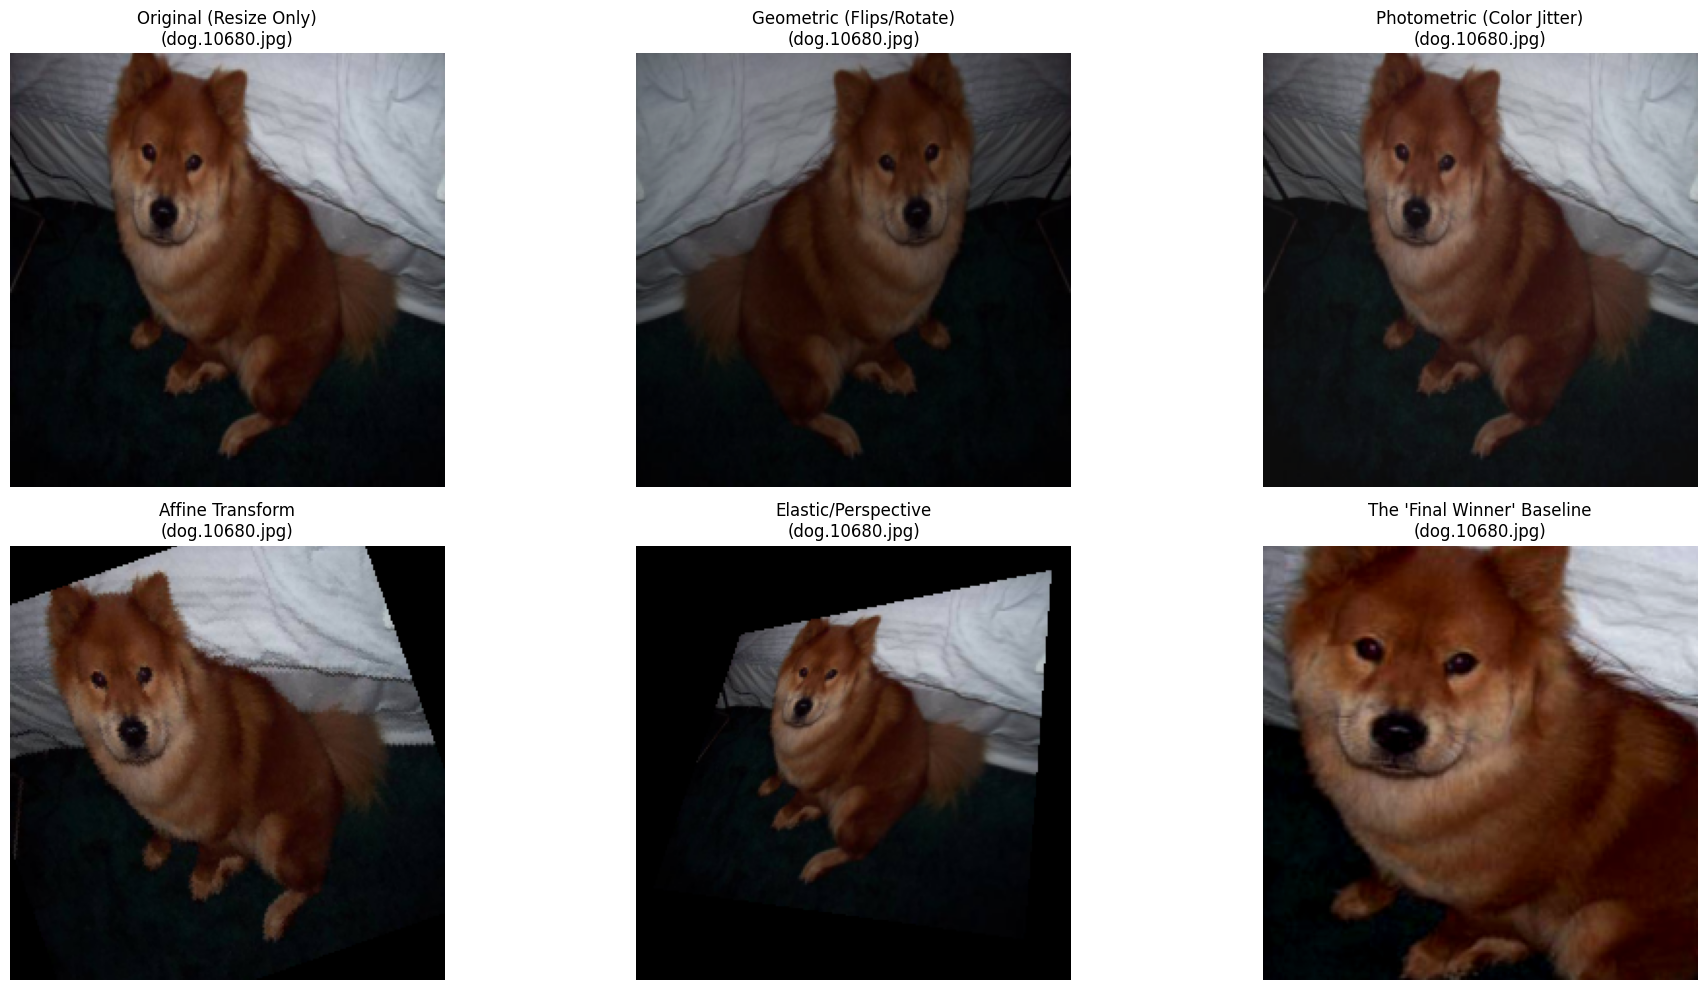

In [ ]:
def get_random_img_pth(dir_path):
    cls = random.choice(['cats', 'dogs'])
    cls_dir = os.path.join(dir_path, cls)
    img_name = random.choice(os.listdir(cls_dir))
    return os.path.join(cls_dir, img_name)

# try different data augmentations
augmentations = {
    "Original (Resize Only)": transforms.Compose([
        transforms.Resize((224, 224))
    ]),
    
    "Geometric (Flips/Rotate)": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0), # Forced on for visualization
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2)
    ]),
    
    "Photometric (Color Jitter)": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
    ]),
    
    "Affine Transform": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomAffine(degrees=30, translate=(0.1, 0.1), scale=(0.8, 1.2))
    ]),
    
    "Elastic/Perspective": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomPerspective(distortion_scale=0.5, p=1.0)
    ]),
    
    "The 'Final Winner' Baseline": transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.2, 0.2, 0.2)
    ])
}

data_dir = 'ecse-415-winter-2026-dog-vs-cat-classification/train/train'
img_path = get_random_img_pth(data_dir)
img = Image.open(img_path).convert('RGB')

plt.figure(figsize=(20, 10))

for i, (name, policy) in enumerate(augmentations.items()):
    augmented_img = policy(img)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented_img)
    plt.title(f"{name}\n({img_path.split(os.sep)[-1]})", fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()